# Pre-Processing

## Handling Missing Value

In [153]:
import pandas as pd

file_path = "efotw-2024-master-index-data-for-researchers-iso.xlsx"
xls = pd.ExcelFile(file_path)

df1_raw = xls.parse("EFW Data 2024 Report", skiprows=3)
df1_raw.columns = df1_raw.iloc[0]
df1 = df1_raw[1:].dropna(how="all", axis=1)
df1.columns = [str(col).strip().replace(" ", "_") for col in df1.columns]
df1_clean = df1.dropna(subset=["Year", "Countries", "Economic_Freedom_Summary_Index"])

df2 = xls.parse("EFW Panel Data 2024 Report")
df2.columns = [col.strip().replace(" ", "_") for col in df2.columns]
df2_clean = df2.dropna(subset=["Summary", "Area_1", "Area_2", "Area_3", "Area_4", "Area_5"])

df3 = xls.parse("EFW Data 1950-1965")
df3.columns = ["Year", "Country", "EFW"]
df3_clean = df3.dropna(subset=["EFW"])


In [154]:
df1_clean

,Year,ISO_Code_2,ISO_Code_3,Countries,Economic_Freedom_Summary_Index,Rank,Quartile,Government_consumption,data,Transfers_and_subsidies,...,Tax_compliance,Business_regulations,Market_openness,Business_Permits,Distorton_of_the_business_environment,Freedom_to_enter_markets_and_compete,Regulation,Area_5_Rank,World_Bank_Region,"World_Bank_Current_Income_Classification,_1990-Present"
1,2022,AL,ALB,Albania,7.48,38,1,8.282353,11.84,7.133515,...,3.587625,5.379721,6.810619,5.62194,6.25,6.22752,6.897016,55,Europe & Central Asia,UM
2,2022,DZ,DZA,Algeria,4.46,161,4,3.491176,28.13,7.817129,...,4.764764,3.841924,4.641448,8.771111,2.583207,5.331922,4.508463,156,Middle East & North Africa,LM
3,2022,AO,AGO,Angola,4.79,155,4,7.944118,12.99,9.702997,...,4.641462,4.443797,3.427185,7.916416,1.25,4.197867,5.302379,140,Sub-Saharan Africa,LM
4,2022,AR,ARG,Argentina,4.55,159,4,6.167647,19.03,5.536785,...,4.504147,4.969248,6.144822,5.726521,3.380395,5.083913,4.804769,148,Latin America & the Caribbean,UM
5,2022,AM,ARM,Armenia,7.49,36,1,7.058824,16,7.882834,...,6.020369,5.56686,5.590883,9.302574,5,6.631152,7.09543,45,Europe & Central Asia,UM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4778,1970,GB,GBR,United Kingdom,6.33,35,2,5.116058,22.605401,NaN,...,NaN,8.8525,NaN,NaN,NaN,NaN,8.130042,10,Europe & Central Asia,NaN
4779,1970,US,USA,United States,7.89,8,1,5.108942,22.629598,7.980926,...,NaN,7.43,NaN,NaN,NaN,NaN,7.212008,27,North America,NaN
4780,1970,UY,URY,Uruguay,6.62,31,2,6.754035,17.036281,7.413572,...,NaN,4.445,NaN,NaN,NaN,NaN,7.005368,31,Latin America & the Caribbean,NaN
4781,1970,VE,VEN,"Venezuela, RB",7.28,15,1,6.602003,17.553191,9.82743,...,NaN,6.2725,NaN,NaN,NaN,NaN,6.524743,41,Latin America & the Caribbean,NaN


In [155]:
df2_clean

,ISO_Code,Countries,Year,Summary,Area_1,Area_2,Area_3,Area_4,Area_5,Standard_Deviation_of_the_5_EFW_Areas
0,ALB,Albania,2022,7.480000,7.807816,5.433256,8.755898,8.527913,6.897016,1.356691
1,DZA,Algeria,2022,4.460000,4.448090,3.816032,6.370765,3.137295,4.508463,1.205993
2,AGO,Angola,2022,4.790000,7.504494,3.171747,4.996866,2.969500,5.302379,1.844367
3,ARG,Argentina,2022,4.550000,6.218958,4.953806,2.545162,4.217939,4.804769,1.336320
4,ARM,Armenia,2022,7.490000,8.005760,5.814761,8.469577,8.079520,7.095430,1.064798
...,...,...,...,...,...,...,...,...,...,...
4773,TUR,Türkiye,1970,4.207529,4.763477,4.650944,10.000000,0.229228,5.964760,3.492663
4777,GBR,United Kingdom,1970,6.071964,4.623578,7.476323,7.312216,4.150771,7.191775,1.621885
4778,USA,United States,1970,7.715140,5.349535,8.723227,9.587541,8.579729,6.522397,1.752241
4779,URY,Uruguay,1970,5.797037,6.762608,5.415520,5.479744,6.726412,4.547358,0.949134


In [156]:
df3_clean

,Year,Country,EFW
0,1965,Albania,3.154986
1,1965,Algeria,3.620829
2,1965,Angola,3.982971
3,1965,Argentina,5.675413
4,1965,Australia,7.387365
...,...,...,...
453,1950,Czech Rep.,3.085343
454,1950,Burundi,3.070274
455,1950,China,3.050404
456,1950,Russia,3.035994


## Integration and Rename Column Name

In [157]:
df1_subset = df1_clean[['Year', 'Countries', 'Economic_Freedom_Summary_Index', 'World_Bank_Region']].rename(columns={
    'Countries': 'Country'
})

df3_subset = df3_clean[['Year', 'Country', 'EFW']].rename(columns={
    'EFW': 'Economic_Freedom_Summary_Index'
})
df3_subset['World_Bank_Region'] = pd.NA 
combined_df = pd.concat([df1_subset, df3_subset], ignore_index=True)


In [158]:
combined_df

,Year,Country,Economic_Freedom_Summary_Index,World_Bank_Region
0,2022,Albania,7.48,Europe & Central Asia
1,2022,Algeria,4.46,Middle East & North Africa
2,2022,Angola,4.79,Sub-Saharan Africa
3,2022,Argentina,4.55,Latin America & the Caribbean
4,2022,Armenia,7.49,Europe & Central Asia
...,...,...,...,...
4840,1950,Czech Rep.,3.085343,NaN
4841,1950,Burundi,3.070274,NaN
4842,1950,China,3.050404,NaN
4843,1950,Russia,3.035994,NaN


## Handling Missing Value in World Bank Region

In [159]:
country_name_map = {
    'Russia': 'Russian Federation',
    'Czech Rep.' : 'Czechia',
    "Cote d'Ivoire": "Côte d'Ivoire",
    'Central Afr. Rep.':'Central African Republic',
    'Congo, Dem. R.' : 'Congo, Dem. Rep.',
    'Congo, Rep. Of': 'Congo, Rep.',
    'Dominican Rep.': 'Dominican Republic',
    'Egypt': 'Egypt, Arab Rep.',
    'Hong Kong' : 'Hong Kong SAR, China',
    'Iran' :'Iran, Islamic Rep.',
    'Korea, South': 'Korea, Rep.',
    'Pap. New Guinea':'Papua New Guinea',
    'Syria' : 'Syrian Arab Republic',
    'Trinidad & Tob.':'Trinidad and Tobago',
    'Turkey':'Türkiye',
    'Venezuela':'Venezuela, RB'
}

combined_df['Country'] = combined_df['Country'].replace(country_name_map)


In [160]:
missing_region = combined_df[combined_df['World_Bank_Region'].isna()]

region_map = df1_subset[['Country', 'World_Bank_Region']].dropna().drop_duplicates()

filled_region = missing_region.drop(columns='World_Bank_Region').merge(region_map, on='Country', how='left')

has_region = combined_df[combined_df['World_Bank_Region'].notna()]
combined_filled = pd.concat([has_region, filled_region], ignore_index=True)


In [161]:
combined_filled

,Year,Country,Economic_Freedom_Summary_Index,World_Bank_Region
0,2022,Albania,7.48,Europe & Central Asia
1,2022,Algeria,4.46,Middle East & North Africa
2,2022,Angola,4.79,Sub-Saharan Africa
3,2022,Argentina,4.55,Latin America & the Caribbean
4,2022,Armenia,7.49,Europe & Central Asia
...,...,...,...,...
4840,1950,Czechia,3.085343,Europe & Central Asia
4841,1950,Burundi,3.070274,Sub-Saharan Africa
4842,1950,China,3.050404,East Asia & Pacific
4843,1950,Russian Federation,3.035994,Europe & Central Asia


## Convert Data Type

In [162]:
combined_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Year                            4845 non-null   object
 1   Country                         4845 non-null   object
 2   Economic_Freedom_Summary_Index  4845 non-null   object
 3   World_Bank_Region               4845 non-null   object
dtypes: object(4)
memory usage: 151.5+ KB


In [163]:
combined_filled["Year"] = pd.to_datetime(combined_filled["Year"], format="%Y", errors='coerce')

In [164]:
combined_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Year                            4845 non-null   datetime64[ns]
 1   Country                         4845 non-null   object        
 2   Economic_Freedom_Summary_Index  4845 non-null   object        
 3   World_Bank_Region               4845 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 151.5+ KB


## Save to CSV

In [165]:
combined_filled.to_csv('Data_Bersih.csv', index=False)

In [166]:
df2_clean.to_csv('Data_Bersih2.csv', index=False)

# Processing

## Make Atoti Session Numero Uno

In [119]:
!pip install --upgrade atoti



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cube

In [120]:
import atoti as tt

In [121]:
session = tt.Session.start()

In [122]:
store = session.read_pandas(combined_filled, table_name="Economic_Freedom_Summary_Index")

cube = session.create_cube(store, "Economic_Freedom_Summary_Index_Cube")

lvl = cube.levels
hrc = cube.hierarchies
msr = cube.measures


## Schema

In [123]:
session.tables.schema

```mermaid
erDiagram
  "Economic_Freedom_Summary_Index" {
    non-null LocalDate "Year"
    non-null String "Country"
    nullable double "Economic_Freedom_Summary_Index"
    non-null String "World_Bank_Region"
  }
```


## Level

In [124]:
lvl

{('Economic_Freedom_Summary_Index', 'Year', 'Year'): <atoti.level.Level object at 0x000001AF89BF5A90>, ('Economic_Freedom_Summary_Index', 'World_Bank_Region', 'World_Bank_Region'): <atoti.level.Level object at 0x000001AF89BF7D20>, ('Economic_Freedom_Summary_Index', 'Country', 'Country'): <atoti.level.Level object at 0x000001AF89BF5B70>}

## Hierarki

In [125]:
hrc

{('Economic_Freedom_Summary_Index', 'Year'): <atoti.hierarchy.Hierarchy object at 0x000001AFFDED09F0>, ('Economic_Freedom_Summary_Index', 'World_Bank_Region'): <atoti.hierarchy.Hierarchy object at 0x000001AF87CF1010>, ('Economic_Freedom_Summary_Index', 'Country'): <atoti.hierarchy.Hierarchy object at 0x000001AFFDD6C1A0>}

## Measure

In [126]:
msr

{'contributors.COUNT': <atoti.measure.Measure object at 0x000001AF89BF4280>, 'Economic_Freedom_Summary_Index.SUM': <atoti.measure.Measure object at 0x000001AF89BF5080>, 'update.TIMESTAMP': <atoti.measure.Measure object at 0x000001AF89BF42F0>, 'Economic_Freedom_Summary_Index.MEAN': <atoti.measure.Measure object at 0x000001AF89BF40C0>}

### Make New Measure

In [127]:
cube.measures["Economic_Freedom_Summary_Index.SUM"]


In [128]:
year_level = cube.levels[("Economic_Freedom_Summary_Index", "Year", "Year")]
country_level = cube.levels[("Economic_Freedom_Summary_Index", "Country", "Country")]


In [129]:
from atoti import scope

year_level = cube.levels[("Economic_Freedom_Summary_Index", "Year", "Year")]
country_level = cube.levels[("Economic_Freedom_Summary_Index", "Country", "Country")]

msr["EFW_Max_Country"] = (
    tt.agg.max(
        msr["Economic_Freedom_Summary_Index.SUM"],
        scope=scope.OriginScope(levels=[year_level, country_level])
    )
)

In [130]:
from atoti import scope

year_level = cube.levels[("Economic_Freedom_Summary_Index", "Year", "Year")]
country_level = cube.levels[("Economic_Freedom_Summary_Index", "Country", "Country")]

msr["EFW_Min_Country"] = (
    tt.agg.min(
        msr["Economic_Freedom_Summary_Index.SUM"],
        scope=scope.OriginScope(levels=[year_level, country_level])
    )
)

In [131]:
from atoti import scope

year_level = cube.levels[("Economic_Freedom_Summary_Index", "Year", "Year")]
country_level = cube.levels[("Economic_Freedom_Summary_Index", "Country", "Country")]

msr["EFW_Disparity_Country"] = msr["EFW_Max_Country"]-msr["EFW_Min_Country"]

In [132]:
msr

{'contributors.COUNT': <atoti.measure.Measure object at 0x000001AF8871BF50>, 'Economic_Freedom_Summary_Index.SUM': <atoti.measure.Measure object at 0x000001AF88718830>, 'update.TIMESTAMP': <atoti.measure.Measure object at 0x000001AF887191D0>, 'Economic_Freedom_Summary_Index.MEAN': <atoti.measure.Measure object at 0x000001AF8871BE70>, 'EFW_Max_Country': <atoti.measure.Measure object at 0x000001AF8871BD20>, 'EFW_Min_Country': <atoti.measure.Measure object at 0x000001AF8871BEE0>, 'EFW_Disparity_Country': <atoti.measure.Measure object at 0x000001AF8871BC40>}

## Soal Query Untuk Session Atoti 1

### 1. Buatlah sebuah query untuk menampilkan nilai EFW Indonesia dari tahun 1950-2022!

In [133]:
freedom_index_indonesia = cube.query(
    msr["Economic_Freedom_Summary_Index.SUM"],
    levels=[lvl["Country"], lvl["Year"]]
)

freedom_index_indonesia.reset_index(inplace=True)


freedom_index_indonesia = freedom_index_indonesia[freedom_index_indonesia["Country"] == "Indonesia"]

freedom_index_indonesia = freedom_index_indonesia.sort_values(by="Year", ascending=False)

freedom_index_indonesia


,Country,Year,Economic_Freedom_Summary_Index.SUM
2076,Indonesia,2022-01-01,6.96
2075,Indonesia,2021-01-01,6.94
2074,Indonesia,2020-01-01,6.91
2073,Indonesia,2019-01-01,7.1
2072,Indonesia,2018-01-01,7.11
2071,Indonesia,2017-01-01,7.08
2070,Indonesia,2016-01-01,7.06
2069,Indonesia,2015-01-01,6.9
2068,Indonesia,2014-01-01,6.85
2067,Indonesia,2013-01-01,6.8


In [134]:
freedom_index_indonesia["Year"] = freedom_index_indonesia["Year"].dt.year

In [135]:
freedom_index_indonesia

,Country,Year,Economic_Freedom_Summary_Index.SUM
2076,Indonesia,2022,6.96
2075,Indonesia,2021,6.94
2074,Indonesia,2020,6.91
2073,Indonesia,2019,7.1
2072,Indonesia,2018,7.11
2071,Indonesia,2017,7.08
2070,Indonesia,2016,7.06
2069,Indonesia,2015,6.9
2068,Indonesia,2014,6.85
2067,Indonesia,2013,6.8


Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
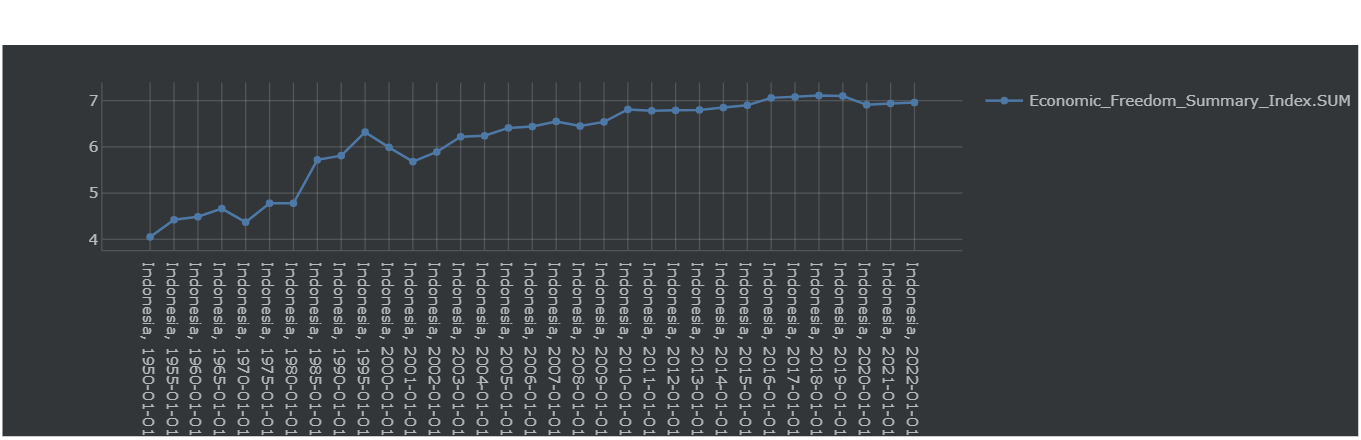

In [136]:
session.widget

### 2. Buatlah query untuk menampilkan rata-rata EFW setiap negara dari 1950-2022

In [150]:
EFW_Negara_All_Time = cube.query(
    msr["Economic_Freedom_Summary_Index.MEAN"],
    levels=[lvl["Country"], lvl["Year"]]
)

EFW_Negara_All_Time.reset_index(inplace=True)

EFW_Negara_All_Time = (
    EFW_Negara_All_Time
    .groupby("Country")["Economic_Freedom_Summary_Index.MEAN"]
    .mean()
    .reset_index()
    .rename(columns={"Economic_Freedom_Summary_Index.MEAN": "EFW_Mean_1950_2022"})
    .sort_values(by="EFW_Mean_1950_2022", ascending=False)
)

EFW_Negara_All_Time

,Country,EFW_Mean_1950_2022
66,"Hong Kong SAR, China",8.930246
143,Switzerland,8.381676
133,Singapore,8.351034
158,United States,8.272658
109,New Zealand,8.117005
...,...,...
160,"Venezuela, RB",4.329588
164,Zimbabwe,4.320551
72,Iraq,4.286
105,Myanmar,4.024072


### Challanges Pak Harmon

In [151]:
EFW_Negara_All_Time = cube.query(
    msr["Economic_Freedom_Summary_Index.MEAN"],
    levels=[lvl["Country"], lvl["Year"]]
)

EFW_Negara_All_Time.reset_index(inplace=True)

EFW_Indonesia = EFW_Negara_All_Time[EFW_Negara_All_Time["Country"] == "Indonesia"]

EFW_Indonesia  = (
    EFW_Indonesia 
    .groupby("Country")["Economic_Freedom_Summary_Index.MEAN"]
    .mean()
    .reset_index()
    .rename(columns={"Economic_Freedom_Summary_Index.MEAN": "EFW_Mean_1950_2022"})
    .sort_values(by="EFW_Mean_1950_2022", ascending=False)
)

EFW_Indonesia 

,Country,EFW_Mean_1950_2022
0,Indonesia,6.118329


In [152]:
EFW_Negara_All_Time = cube.query(
    msr["Economic_Freedom_Summary_Index.MEAN"],
    levels=[lvl["Country"], lvl["Year"]]
)

EFW_Negara_All_Time.reset_index(inplace=True)

EFW_Singapore = EFW_Negara_All_Time[EFW_Negara_All_Time["Country"] == "Singapore"]

EFW_Singapore = (
    EFW_Singapore
    .groupby("Country")["Economic_Freedom_Summary_Index.MEAN"]
    .mean()
    .reset_index()
    .rename(columns={"Economic_Freedom_Summary_Index.MEAN": "EFW_Mean_1950_2022"})
    .sort_values(by="EFW_Mean_1950_2022", ascending=False)
)

EFW_Singapore

,Country,EFW_Mean_1950_2022
0,Singapore,8.351034


### 3. Buatlah query untuk menampilkan nilai EFW World Bank Region terkecil beserta negaranya untuk setiap tahun 

In [138]:
Kelompok_dos = cube.query(
    msr["Economic_Freedom_Summary_Index.MEAN"],
    levels=[lvl["World_Bank_Region"], lvl["Country"], lvl["Year"]]
)

Kelompok_dos.reset_index(inplace=True)
Kelompok_dos["Year"] = pd.to_datetime(Kelompok_dos["Year"]).dt.year

min_efw_per_year = (
    Kelompok_dos.loc[
        Kelompok_dos.groupby("Year")["Economic_Freedom_Summary_Index.MEAN"].idxmin()
    ]
    .sort_values("Year")
    .reset_index(drop=True)
)

print("World Bank Region dan Negara dengan EFW terkecil untuk setiap tahun:\n")
min_efw_per_year[["Year", "World_Bank_Region", "Country", "Economic_Freedom_Summary_Index.MEAN"]]


World Bank Region dan Negara dengan EFW terkecil untuk setiap tahun:



,Year,World_Bank_Region,Country,Economic_Freedom_Summary_Index.MEAN
0,1950,South Asia,Nepal,2.93945
1,1955,Sub-Saharan Africa,Burundi,3.08208
2,1960,Europe & Central Asia,Albania,3.154217
3,1965,Europe & Central Asia,Albania,3.154986
4,1970,South Asia,Nepal,2.89
5,1975,East Asia & Pacific,Myanmar,2.1
6,1980,Sub-Saharan Africa,"Congo, Dem. Rep.",2.47
7,1985,Latin America & the Caribbean,Nicaragua,2.09
8,1990,East Asia & Pacific,Myanmar,1.83
9,1995,East Asia & Pacific,Myanmar,2.12


### 4. Buatlah query yang menampilkan nilai rata-rata EFW untuk setiap World Bank Region dari tahun 1950-2022

In [143]:
Kelompok_dos = cube.query(
    msr["Economic_Freedom_Summary_Index.MEAN"],
    levels=[lvl["World_Bank_Region"], lvl["Year"]]
)

Kelompok_dos.reset_index(inplace=True)
Kelompok_dos["Year"] = pd.to_datetime(Kelompok_dos["Year"]).dt.year

rata_rata_region = (
    Kelompok_dos.groupby("World_Bank_Region")["Economic_Freedom_Summary_Index.MEAN"]
    .mean()
    .reset_index()
    .rename(columns={"Economic_Freedom_Summary_Index.MEAN": "Mean_EFW_AllTime"})
    .sort_values(by="Mean_EFW_AllTime", ascending=False)
)

print("Rata-rata EFW per World Bank Region (All Time):\n")
rata_rata_region

Rata-rata EFW per World Bank Region (All Time):



,World_Bank_Region,Mean_EFW_AllTime
4,North America,8.16371
1,Europe & Central Asia,6.89652
0,East Asia & Pacific,6.59191
2,Latin America & the Caribbean,6.392265
5,South Asia,5.741222
3,Middle East & North Africa,5.639734
6,Sub-Saharan Africa,5.336251


Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
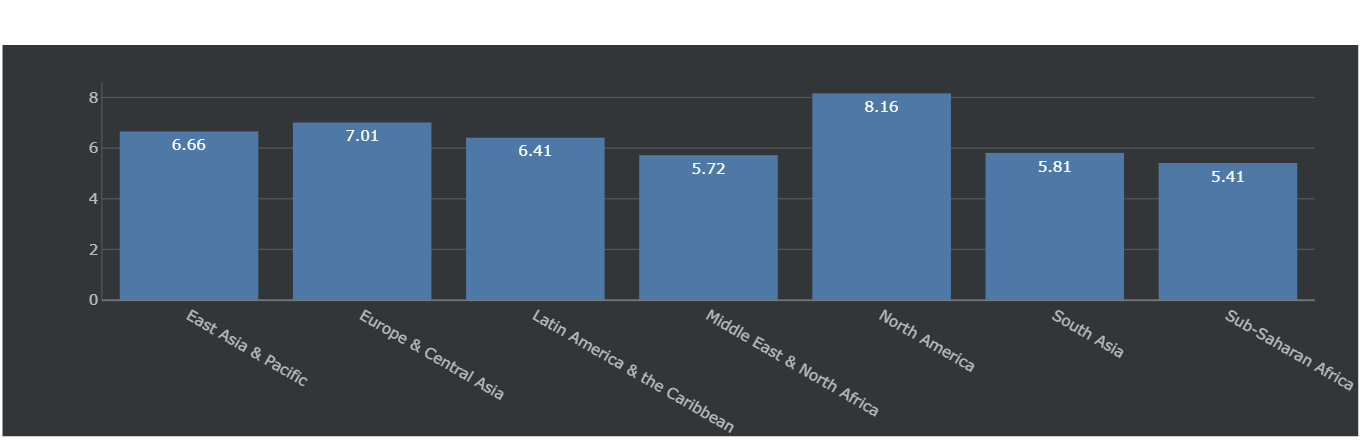

In [82]:
session.widget

## Make Atoti Session Numero Dos

In [83]:
df2_clean

,ISO_Code,Countries,Year,Summary,Area_1,Area_2,Area_3,Area_4,Area_5,Standard_Deviation_of_the_5_EFW_Areas
0,ALB,Albania,2022,7.480000,7.807816,5.433256,8.755898,8.527913,6.897016,1.356691
1,DZA,Algeria,2022,4.460000,4.448090,3.816032,6.370765,3.137295,4.508463,1.205993
2,AGO,Angola,2022,4.790000,7.504494,3.171747,4.996866,2.969500,5.302379,1.844367
3,ARG,Argentina,2022,4.550000,6.218958,4.953806,2.545162,4.217939,4.804769,1.336320
4,ARM,Armenia,2022,7.490000,8.005760,5.814761,8.469577,8.079520,7.095430,1.064798
...,...,...,...,...,...,...,...,...,...,...
4773,TUR,Türkiye,1970,4.207529,4.763477,4.650944,10.000000,0.229228,5.964760,3.492663
4777,GBR,United Kingdom,1970,6.071964,4.623578,7.476323,7.312216,4.150771,7.191775,1.621885
4778,USA,United States,1970,7.715140,5.349535,8.723227,9.587541,8.579729,6.522397,1.752241
4779,URY,Uruguay,1970,5.797037,6.762608,5.415520,5.479744,6.726412,4.547358,0.949134


In [84]:
df2_clean["Year"] = pd.to_datetime(df2_clean["Year"], format="%Y", errors='coerce')

C:\Users\USER\AppData\Local\Temp\ipykernel_34208\3547991103.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_clean["Year"] = pd.to_datetime(df2_clean["Year"], format="%Y", errors='coerce')


In [85]:
df2_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3943 entries, 0 to 4780
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   ISO_Code                               3943 non-null   object        
 1   Countries                              3943 non-null   object        
 2   Year                                   3943 non-null   datetime64[ns]
 3   Summary                                3943 non-null   float64       
 4   Area_1                                 3943 non-null   float64       
 5   Area_2                                 3943 non-null   float64       
 6   Area_3                                 3943 non-null   float64       
 7   Area_4                                 3943 non-null   float64       
 8   Area_5                                 3943 non-null   float64       
 9   Standard_Deviation_of_the_5_EFW_Areas  3943 non-null   float64      

In [86]:
import atoti as tt

In [87]:
session = tt.Session.start()

In [88]:
store = session.read_pandas(df2_clean, table_name="Panel")

cube = session.create_cube(store, "panel_Cube")

lvl = cube.levels
hrc = cube.hierarchies
msr = cube.measures


In [89]:
session.tables.schema

```mermaid
erDiagram
  "Panel" {
    non-null String "ISO_Code"
    non-null String "Countries"
    non-null LocalDate "Year"
    nullable double "Summary"
    nullable double "Area_1"
    nullable double "Area_2"
    nullable double "Area_3"
    nullable double "Area_4"
    nullable double "Area_5"
    nullable double "Standard_Deviation_of_the_5_EFW_Areas"
  }
```


In [101]:
lvl

{('Panel', 'ISO_Code', 'ISO_Code'): <atoti.level.Level object at 0x000001AF89063BD0>, ('Panel', 'Year', 'Year'): <atoti.level.Level object at 0x000001AFFDED1470>, ('Panel', 'Countries', 'Countries'): <atoti.level.Level object at 0x000001AFFDED1390>}

In [91]:
hrc

{('Panel', 'ISO_Code'): <atoti.hierarchy.Hierarchy object at 0x000001AFFDED1160>, ('Panel', 'Year'): <atoti.hierarchy.Hierarchy object at 0x000001AFFDED12B0>, ('Panel', 'Countries'): <atoti.hierarchy.Hierarchy object at 0x000001AFFDED3380>}

In [92]:
msr

{'Area_3.SUM': <atoti.measure.Measure object at 0x000001AF81C39A20>, 'Area_2.SUM': <atoti.measure.Measure object at 0x000001AFFDA1A510>, 'Area_1.SUM': <atoti.measure.Measure object at 0x000001AFFDA1A970>, 'Area_3.MEAN': <atoti.measure.Measure object at 0x000001AFFDA1B8C0>, 'Standard_Deviation_of_the_5_EFW_Areas.SUM': <atoti.measure.Measure object at 0x000001AFFDD6D0F0>, 'Summary.SUM': <atoti.measure.Measure object at 0x000001AFFDD6CF30>, 'Area_4.MEAN': <atoti.measure.Measure object at 0x000001AFFDD6D160>, 'Area_1.MEAN': <atoti.measure.Measure object at 0x000001AFFDD6F540>, 'contributors.COUNT': <atoti.measure.Measure object at 0x000001AFFDD6F3F0>, 'Standard_Deviation_of_the_5_EFW_Areas.MEAN': <atoti.measure.Measure object at 0x000001AFFDD6F4D0>, 'Area_5.MEAN': <atoti.measure.Measure object at 0x000001AFFDD6F5B0>, 'Area_2.MEAN': <atoti.measure.Measure object at 0x000001AFFDD6F620>, 'Summary.MEAN': <atoti.measure.Measure object at 0x000001AFFDD6F230>, 'Area_5.SUM': <atoti.measure.Measure object at 0x000001AFFDD6F460>, 'update.TIMESTAMP': <atoti.measure.Measure object at 0x000001AFFDD6CD00>, 'Area_4.SUM': <atoti.measure.Measure object at 0x000001AFFDD6F310>}

### 5. Buatlah query yang menampilkan negara dengan nilai EFW terbesar untuk setiap areanya dari 1970-2022 

In [93]:
df_area = cube.query(
    msr["Area_1.SUM"],
    msr["Area_2.SUM"],
    msr["Area_3.SUM"],
    msr["Area_4.SUM"],
    msr["Area_5.SUM"],
    levels=[lvl["Countries"], lvl["Year"]]
)

df_area.reset_index(inplace=True)

df_area["Year"] = pd.to_datetime(df_area["Year"]).dt.year

top1_per_year_area = []

for area in ["Area_1.SUM", "Area_2.SUM", "Area_3.SUM", "Area_4.SUM", "Area_5.SUM"]:
    top1 = df_area.loc[df_area.groupby("Year")[area].idxmax()][["Year", "Countries", area]].copy()
    top1["Area"] = area
    top1.rename(columns={"Countries": "Country", area: "Score"}, inplace=True)
    top1_per_year_area.append(top1)

top_eins = pd.concat(top1_per_year_area, ignore_index=True)

top_eins.sort_values(by=["Year", "Area"], inplace=True)

top_eins

,Year,Country,Score,Area
0,1970,"Hong Kong SAR, China",9.496497,Area_1.SUM
29,1970,Denmark,9.465278,Area_2.SUM
58,1970,Türkiye,10.0,Area_3.SUM
87,1970,Ghana,10.0,Area_4.SUM
116,1970,"Hong Kong SAR, China",8.674942,Area_5.SUM
...,...,...,...,...
28,2022,Guatemala,9.061474,Area_1.SUM
57,2022,Denmark,9.101094,Area_2.SUM
86,2022,Japan,9.551733,Area_3.SUM
115,2022,"Hong Kong SAR, China",9.661213,Area_4.SUM


### 6. Buatlah query yang menampilkan nilai setiap area di Negara Indonesia pada tahun 1970-2022

In [105]:
df_indonesia = cube.query(
    msr["Area_1.MEAN"],
    msr["Area_2.MEAN"],
    msr["Area_3.MEAN"],
    msr["Area_4.MEAN"],
    msr["Area_5.MEAN"],
    levels=[lvl["Countries"], lvl["Year"]]
)

df_indonesia.reset_index(inplace=True)
df_indonesia = df_indonesia[df_indonesia["Countries"] == "Indonesia"]

df_indonesia = df_indonesia.sort_values(by="Year")

df_indonesia


,Countries,Year,Area_1.MEAN,Area_2.MEAN,Area_3.MEAN,Area_4.MEAN,Area_5.MEAN
1667,Indonesia,1970-01-01,7.393116,1.978469,5.233948,3.61792,2.677819
1668,Indonesia,1975-01-01,7.230876,2.645724,6.456996,4.806841,2.536964
1669,Indonesia,1980-01-01,6.482633,2.6278,6.61353,5.460666,2.442187
1670,Indonesia,1985-01-01,7.627711,2.737966,8.791735,6.007661,3.071779
1671,Indonesia,1990-01-01,7.921864,2.482223,8.280251,6.264488,3.934275
1672,Indonesia,1995-01-01,8.005761,3.226747,8.840616,6.003787,4.267876
1673,Indonesia,2000-01-01,8.072395,3.45051,6.213268,7.076652,4.821651
1674,Indonesia,2001-01-01,8.042073,3.415001,5.55231,7.148999,3.969838
1675,Indonesia,2002-01-01,7.903987,3.671647,5.9986,7.140791,4.45576
1676,Indonesia,2003-01-01,7.717891,4.02766,7.171762,7.322469,4.543393


In [95]:
df_indonesia["Year"] = df_indonesia["Year"].dt.year

In [96]:
df_indonesia

,Countries,Year,Area_1.MEAN,Area_2.MEAN,Area_3.MEAN,Area_4.MEAN,Area_5.MEAN
1667,Indonesia,1970,7.393116,1.978469,5.233948,3.61792,2.677819
1668,Indonesia,1975,7.230876,2.645724,6.456996,4.806841,2.536964
1669,Indonesia,1980,6.482633,2.6278,6.61353,5.460666,2.442187
1670,Indonesia,1985,7.627711,2.737966,8.791735,6.007661,3.071779
1671,Indonesia,1990,7.921864,2.482223,8.280251,6.264488,3.934275
1672,Indonesia,1995,8.005761,3.226747,8.840616,6.003787,4.267876
1673,Indonesia,2000,8.072395,3.45051,6.213268,7.076652,4.821651
1674,Indonesia,2001,8.042073,3.415001,5.55231,7.148999,3.969838
1675,Indonesia,2002,7.903987,3.671647,5.9986,7.140791,4.45576
1676,Indonesia,2003,7.717891,4.02766,7.171762,7.322469,4.543393


Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
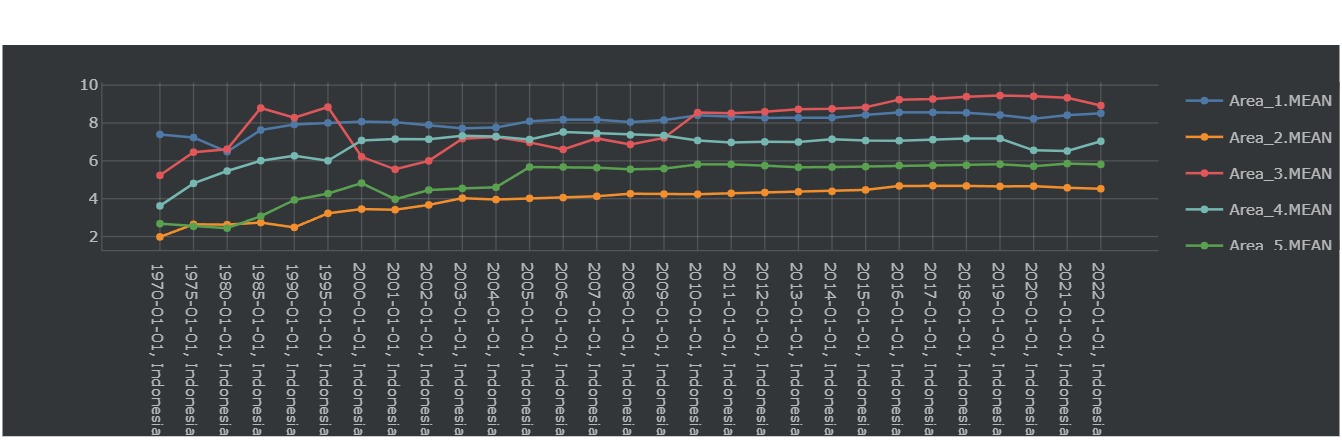

In [97]:
session.widget

# Post-processing 

In [98]:
import pika
import json

def kirim_dataframe_ke_rabbitmq(df, table_name, queue_name='data_queue'):
    try:
        connection = pika.BlockingConnection(pika.ConnectionParameters('localhost'))
        channel = connection.channel()

        channel.queue_declare(queue=queue_name)

        data_json = df.to_json(orient='records')

        pesan = json.dumps({
            "table": table_name,
            "data": data_json
        })

        channel.basic_publish(exchange='', routing_key=queue_name, body=pesan)
        print(f"Data tabel'{table_name}' berhasil dikirim ke RabbitMQ.")

        connection.close()
    except Exception as e:
        print(f"Adios: {e}")

In [99]:
kirim_dataframe_ke_rabbitmq(freedom_index_indonesia, "freedom_index_indonesia")
kirim_dataframe_ke_rabbitmq(EFW_Negara_All_Time, "EFW_Negara_All_Time")
kirim_dataframe_ke_rabbitmq(min_efw_per_year, "min_efw_per_year")
kirim_dataframe_ke_rabbitmq(rata_rata_region, "rata_rata_region")
kirim_dataframe_ke_rabbitmq(top_eins, "top_eins")
kirim_dataframe_ke_rabbitmq(df_indonesia, "df_indonesia")

Data tabel'freedom_index_indonesia' berhasil dikirim ke RabbitMQ.
Data tabel'EFW_Negara_All_Time' berhasil dikirim ke RabbitMQ.
Data tabel'min_efw_per_year' berhasil dikirim ke RabbitMQ.
Data tabel'rata_rata_region' berhasil dikirim ke RabbitMQ.
Data tabel'top_eins' berhasil dikirim ke RabbitMQ.
Data tabel'df_indonesia' berhasil dikirim ke RabbitMQ.
